# Anforderungen an Projektumsetzung: Clustering

In [2]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt



#### Führen Sie mit dem Algorithmus Ihrer Wahl eine Clusteranalyse auf Ihren Daten durch.

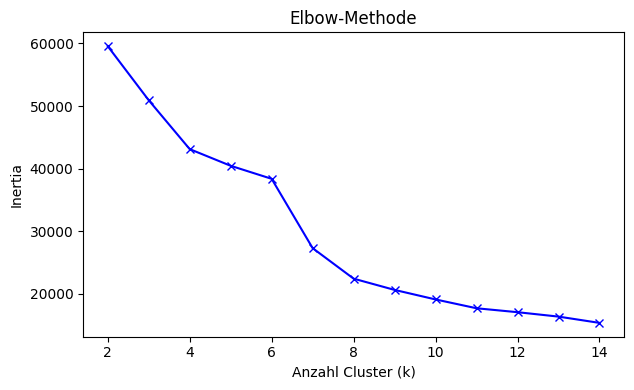

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Daten mit spezifischen Spalten laden
columns_to_use = ['MaxAge', 'YearsCode', 'WorkExp', 'JobSat', 'ConvertedCompYearly']
df = pd.read_csv("survey_results_shortened.csv", usecols=columns_to_use)

# 2. Fehlende Werte behandeln
df_clean = df.dropna()

# 3. Daten skalieren
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

# 4. Beste Clusteranzahl finden
K = range(2, 15)
inertias = []


for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)


# 5. Elbow- und Silhouetten-Plots
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(K, inertias, 'bx-')
plt.title('Elbow-Methode')
plt.xlabel('Anzahl Cluster (k)')
plt.ylabel('Inertia')

plt.tight_layout()
plt.show()

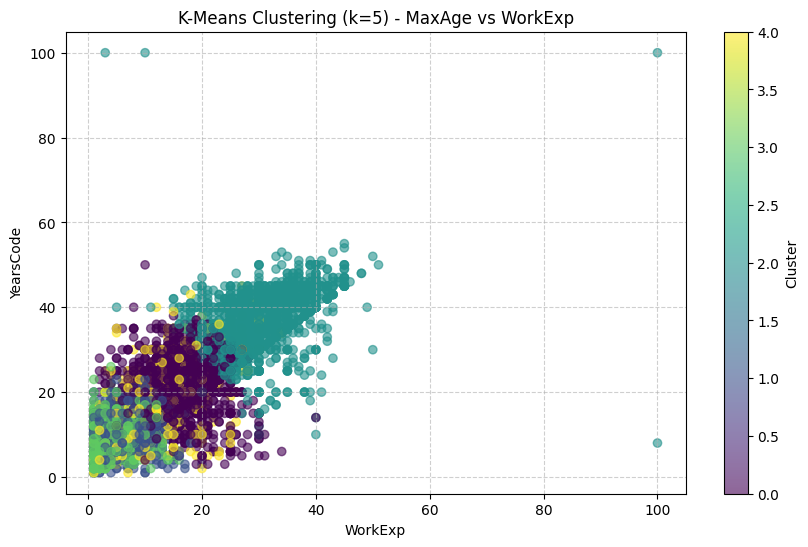


Cluster-Statistiken:
         MaxAge  YearsCode  WorkExp  JobSat  ConvertedCompYearly
Cluster                                                         
0         44.95      21.40    16.24    7.76            134635.55
1         34.74      11.10     7.11    8.68             84492.56
2         57.03      35.08    28.97    7.55            131233.79
3         31.45       9.51     5.36    6.38             60514.36
4         40.42      16.35    11.66    3.12            101083.52


/var/folders/vm/tb68y06x7lg_5g9rt33t290w0000gn/T/ipykernel_66867/3607041010.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Cluster'] = clusters


In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

best_k = 5

# 7. Finales Modell
final_kmeans = KMeans(n_clusters=best_k, random_state=42)
clusters = final_kmeans.fit_predict(X_scaled)

# 8. Visualisierung mit MaxAge und WorkExp
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_clean['WorkExp'],
                     df_clean['YearsCode'],
                     c=clusters,
                     cmap='viridis',
                     alpha=0.6)
plt.xlabel('WorkExp')
plt.ylabel('YearsCode')
plt.title(f'K-Means Clustering (k={best_k}) - MaxAge vs WorkExp')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 9. Cluster-Statistiken
df_clean['Cluster'] = clusters
print("\nCluster-Statistiken:")
print(df_clean.groupby('Cluster')[columns_to_use].mean().round(2))

In [15]:
df

,MainBranch,Age,MaxAge,AgeNum,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,i am a developer by profession,25-34 years old,34.0,29.0,master's degree,employed,"['caring for dependents (children, elderly, et...",8.0,"yes, i am not new to coding but am learning ne...",['online courses or certification (includes al...,...,['vertex ai'],[],[],[],['chatgpt'],[],"[""when i don't trust ai's answers""]","['troubleshooting, profiling, debugging']",61256.0,10.0
1,i am a developer by profession,25-34 years old,34.0,29.0,associate degree,employed,[],2.0,"yes, i am not new to coding but am learning ne...","['books / physical media', 'online courses or ...",...,[],[],[],[],[],[],"[""when i don't trust ai's answers"", 'when i ha...",['all skills. ai is a flop.'],104413.0,9.0
2,i am a developer by profession,35-44 years old,44.0,39.0,bachelor's degree,"independent contractor, freelancer, or self-em...",['none of the above'],10.0,"yes, i am not new to coding but am learning ne...",['online courses or certification (includes al...,...,[],[],[],[],"['chatgpt', 'claude code', 'github copilot', '...",[],"[""when i don't trust ai's answers"", 'when i ha...","['understand how things actually work, problem...",53061.0,8.0
3,i am a developer by profession,35-44 years old,44.0,39.0,bachelor's degree,employed,['none of the above'],4.0,"yes, i am not new to coding but am learning ne...","['ai codegen tools or ai-enabled apps', 'other...",...,[],[],[],[],"['chatgpt', 'claude code']",[],"[""when i don't trust ai's answers"", 'when i ha...",[],36197.0,6.0
4,i am a developer by profession,35-44 years old,44.0,39.0,master's degree,"independent contractor, freelancer, or self-em...","['caring for dependents (children, elderly, et...",21.0,"no, i am not new to coding and did not learn n...",[],...,[],[],[],[],[],[],"[""when i don't trust ai's answers""]","['critical thinking, the skill to define the t...",60000.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30190,i am a developer by profession,35-44 years old,44.0,39.0,professional degree,employed,['none of the above'],10.0,"no, i am not new to coding and did not learn n...",[],...,[],[],[],[],[],[],"[""when i don't trust ai's answers"", 'when i ha...","['ingenuity in algorithmic and optimizations, ...",200000.0,7.0
30191,i am a developer by profession,25-34 years old,34.0,29.0,bachelor's degree,employed,['none of the above'],3.0,"yes, i am not new to coding but am learning ne...",['stack overflow or stack exchange'],...,[],[],[],[],[],[],"[""when i don't trust ai's answers"", 'when i ha...",[],NaN,9.0
30192,i am a developer by profession,25-34 years old,34.0,29.0,master's degree,not employed,['none of the above'],6.0,"yes, i am new to coding or currently a student",[],...,[],[],[],[],[],[],[],[],NaN,NaN
30193,i am a developer by profession,18-24 years old,24.0,21.0,master's degree,employed,['none of the above'],3.0,"yes, i am not new to coding but am learning ne...","['ai codegen tools or ai-enabled apps', 'other...",...,[],[],['grafana + prometheus'],[],[],[],['when i have ethical or security concerns abo...,"['soft skills, ability to use ai tools, genera...",1678.0,8.0


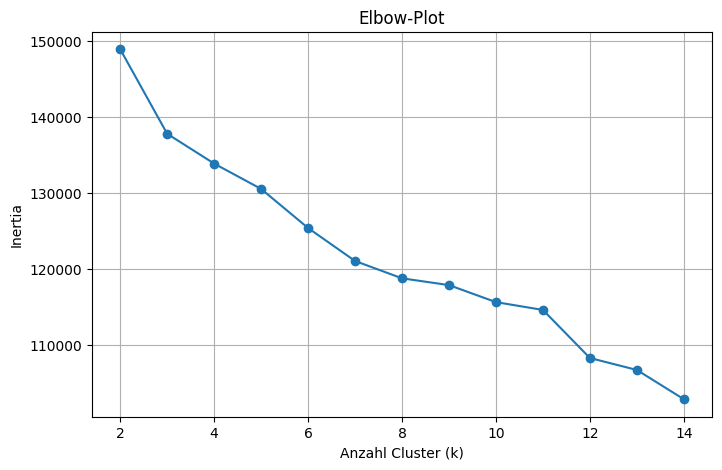


===== Cluster 0 — Top 10 Features =====
Employment_Employed                                               0.992899
EdLevel_Master’s degree                                           0.575353
RemoteWork_Remote                                                 0.260734
RemoteWork_Hybrid (some remote, leans heavy to in-person)         0.226425
OrgSize_20 to 99 employees                                        0.210432
OrgSize_100 to 499 employees                                      0.197359
RemoteWork_Hybrid (some in-person, leans heavy to flexibility)    0.191386
Country_nan                                                       0.189462
RemoteWork_In-person                                              0.174000
EdLevel_Some college/university study without earning a degree    0.170416
Name: 0, dtype: float64

===== Cluster 1 — Top 10 Features =====
RemoteWork_nan                                                     0.998693
OrgSize_nan                                                        0

In [5]:
import pandas as pd, ast
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
import numpy as np

# 1. Lade Datei
df = pd.read_csv("survey_results_shortened.csv")

# 2. Spalten (anpassen falls nötig)
list_columns = [
    "LanguageHaveWorkedWith",
    "LanguageWantToWorkWith",
    "DatabaseHaveWorkedWith",
    "DatabaseWantToWorkWith",
    "DevType"
]

categorical_columns = [
    "EdLevel",
    "Employment",
    "OrgSize",
    "Country",
    "RemoteWork"
]

# 3. Auswahl, parse list-strings
df_selected = df[[c for c in list_columns + categorical_columns if c in df.columns]].copy()

def parse_list(x):
    if isinstance(x, str) and x.startswith("["):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return [] if pd.isna(x) else []

for col in list_columns:
    if col in df_selected.columns:
        df_selected[col] = df_selected[col].apply(parse_list)
        df_selected[col] = df_selected[col].apply(lambda lst: [s.strip().lower() for s in lst])

# 4. Expand & One-Hot für Listen-Spalten (robust!)
expanded_df = df_selected.copy()

for col in list_columns:
    if col not in expanded_df.columns:
        continue

    # explode → dummies → wieder zusammenfassen
    exploded = expanded_df[col].explode()

    # Falls die Spalte komplett leer ist
    if exploded.dropna().empty:
        continue

    dummies = pd.get_dummies(exploded).groupby(level=0).sum()

    dummies = dummies.add_prefix(col + "_")

    # Jetzt sauber anhängen (Index passt!)
    expanded_df = pd.concat([expanded_df, dummies], axis=1)

# Original Listen entfernen
expanded_df = expanded_df.drop(columns=[c for c in list_columns if c in expanded_df.columns])


# 5. One-Hot für normale Kategorien
expanded_df = pd.get_dummies(expanded_df, columns=[c for c in categorical_columns if c in expanded_df.columns], dummy_na=True)

# 6. Feature-Matrix
X = expanded_df.fillna(0)
# pca = PCA(n_components=0.90)  # 90% der Varianz behalten
# X_reduced = pca.fit_transform(X)
#
# print("Vor PCA:", X.shape)
# print("Nach PCA:", X_reduced.shape)

# 7. Elbow: inertias berechnen
Ks = range(2, 15)
inertias = []

# Nur 30.000 Zeilen verwenden (oder weniger falls dein PC schwach ist)
# max_sample = min(30000, X_reduced.shape[0])
# X_sample = X_reduced[:max_sample]

for k in Ks:
    km = MiniBatchKMeans(
        n_clusters=k,
        batch_size=2048,
        random_state=42
    )
    km.fit(X)
    inertias.append(km.inertia_)

# 8. Plot
plt.figure(figsize=(8,5))
plt.plot(list(Ks), inertias, marker='o')
plt.xlabel("Anzahl Cluster (k)")
plt.ylabel("Inertia")
plt.title("Elbow-Plot")
plt.grid(True)
plt.show()

# 9. Wähle best_k per Plot und berechne finale Labels
best_k = 6  # <- durch Plot bestimmen
kmeans_final = MiniBatchKMeans(
    n_clusters=best_k,
    batch_size=2048,
    random_state=42
)
clusters = kmeans_final.fit_predict(X)

df["Cluster"] = clusters

# ================================
# 5. Ausgabe
# ================================
# print(df["Cluster"].value_counts())
# for c in range(6):
#     print(f"\n=== Cluster {c} ===")
#     display(df[df["Cluster"] == c].head(5))

top_n = 10
cluster_profiles = expanded_df.groupby(df["Cluster"]).mean()
cluster_profiles
for c in sorted(df["Cluster"].unique()):
    print(f"\n===== Cluster {c} — Top {top_n} Features =====")
    print(cluster_profiles.loc[c].sort_values(ascending=False).head(top_n))
